# Proyecto del curso Mécanica Celeste 2026-1
## La aproximación de Apophis en 2029
### Jaider Leandro Rueda Isaza

## Unidades canónicas
En este notebook se utilizan las siguientes unidades canónicas:
- L = 1 AU (una unidad astrónomica)
- M = M_sun (una masa solar)
- T = 5033865 s

## Librerias necesarias

In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import plotly.graph_objects as go
from celluloid import Camera
from IPython.display import HTML, display
import spiceypy as spy
from astropy.time import Time
from scipy.optimize import newton

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


## Factores de conversión de unidades

In [31]:
rb.horizons.SSL_CONTEXT = 'unverified' # Para evitar problemas con certificados SSL al acceder a JPL Horizons

# Factores de conversión: SI a Canónicas
m_to_AU = 1.0 / 149597870700.0
kg_to_Msun = 1.0 / 1.98847e30
k_gauss = 0.01720209895
Tc_to_days = 1.0 / k_gauss
Tc_to_s = Tc_to_days * 86400.0
s_to_Tc = 1.0 / Tc_to_s

# Factores de conversión: Canónicas a SI
AU_to_m = 149597870700.0
Msun_to_kg = 1.98847e30

# Factores de conversión extra útiles
km_to_AU = 1000.0 / 149597870700.0
AU_to_km = 149597870700.0 / 1000.0
days_to_Tc = 1.0 / Tc_to_days
years_to_Tc = 365.25 / Tc_to_days
Tc_to_years = Tc_to_days / 365.25

# Velocidad
ms_to_canonical = m_to_AU / s_to_Tc
canonical_to_ms = AU_to_m / Tc_to_s

# Construcción del sistema y visualización

Se crea un sistema usando la libreria Rebound incluyendo el Sol, todos los planetas, la luna, Apophis y otros cuerpos cercanos a la Tierra. La fecha de iniciación se tomó como el primero de Enero del 2026. Los cuerpos se añaden con la función de Rebound "add" usando sus identificaciones. Las masas de varios cuerpos se añaden manualmente ya que Rebound las devuelve como cero.

In [57]:
bodies = [
    ('Apophis','99942'),
    ('Sun', '10'),
    ('Mercury', '1'),
    ('Venus', '2'),
    ('Earth', '399'),
    ('Moon', '301'),
    ('Mars', '499'),
    ('Jupiter', '5'),
    ('Saturn', '6'),
    ('Uranus', '7'),
    ('Neptune', '899'),
    ('Eros', '433'),
    ('Ganymed', '1036'),
    ('Vesta', '4;'),
    ('Ceres', '1;')
]

masses = [
    6.1e10 * kg_to_Msun,       # Apophis
    1.0,   # Sun
    3.3011e23 * kg_to_Msun,    # Mercury
    4.86731e24 * kg_to_Msun,    # Venus
    5.97217e24 * kg_to_Msun,   # Earth
    7.346e22 * kg_to_Msun,   # Moon
    6.4171e23 * kg_to_Msun,    # Mars
    1.898125e27 * kg_to_Msun,   # Jupiter
    5.68317e26 * kg_to_Msun,    # Saturn
    8.68099e25 * kg_to_Msun,    # Uranus  
    1.024092e26 * kg_to_Msun,   # Neptune
    6.687e15 * kg_to_Msun,     # Eros
    1.3e23 * kg_to_Msun,    # Ganymed
    2.590271 * kg_to_Msun,   # Vesta
    9.38392e20 * kg_to_Msun     # Ceres
]

In [58]:
sim_solar = rb.Simulation()
date0 = '2026-01-01'

for label, target in bodies:
    print(f"Adding {label} to the simulation.")
    sim_solar.add(target, date=date0)

for i in range(1, len(sim_solar.particles)):
    sim_solar.particles[i].m = masses[i]


Adding Apophis to the simulation.
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 
Adding Sun to the simulation.
Searching NASA Horizons for '10'... 


c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Sun (10) 
Adding Mercury to the simulation.
Searching NASA Horizons for '1'... 
Found: Mercury Barycenter (199) 
Adding Venus to the simulation.
Searching NASA Horizons for '2'... 
Found: Venus Barycenter (299) 
Adding Earth to the simulation.
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Adding Moon to the simulation.
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Adding Mars to the simulation.
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Adding Jupiter to the simulation.
Searching NASA Horizons for '5'... 
Found: Jupiter Barycenter (5) 
Adding Saturn to the simulation.
Searching NASA Horizons for '6'... 
Found: Saturn Barycenter (6) 
Adding Uranus to the simulation.
Searching NASA Horizons for '7'... 
Found: Uranus Barycenter (7) 
Adding Neptune to the simulation.
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
Adding Eros to the simulation.
Searching NASA Horizons for '433'... 
Found: 433 Eros (A898 PA) 
Adding Ganymed to the simu

In [59]:
sim_solar.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	15
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x2e5b4e3c750, m=0.0 x=0.6306953539299172 y=-0.3977098912292628 z=0.0360513270014221 vx=0.6594530762068974 vy=1.0771195165053096 vz=-0.041908818147308985>
<rebound.particle.Particle object at 0x2e5b6b1f0d0, m=1.0 x=-0.003067316167378725 y=-0.005533329071575706 z=0.00013168419397952 vx=0.00041716254822091994 vy=1.0336727677051391e-05 vz=-7.899371019067428e-06>
<rebound.particle.Particle object at 0x2e5b4e3c750, m=1.6601205952315097e-07 x=-0.21826862054504637 y=-0.4147409447718478 z=-0.013571585397944144 vx=1.1184116781425926 vy=-0.6823265287730099 vz=-0.15831160016258605>
<rebound.particle.Particle object at 0x2e5b6b1f0d0, m=2.447766373141159e-06 x=0.08580993344897782 y=-0.72729571138865

En el siguiente codigo se corrobora si los datos obtenidos de pc.consulta_horizons son iguales a los obtenidos con Rebound

In [60]:
#verificacion si consulta_horizons devuelve valores similares

for i, (label, target) in enumerate(bodies):

    Tabla, jd, X = pc.consulta_horizons(id=target,epochs=date0,location="@SSB")
    X = np.array(X)
    X[0:3] = X[0:3] * m_to_AU
    X[3:6] = X[3:6] * ms_to_canonical

    print(f"Vector de estado de {label} desde consulta horizons: {X}")
    print(f"Vector de estado de {label} desde Rebound: {sim_solar.particles[i].xyz}, {sim_solar.particles[i].vxyz}")
    print(f"diferencia en posición: {np.linalg.norm(X[0:3] - sim_solar.particles[i].xyz)} AU")
    print(f"diferencia en velocidad: {np.linalg.norm(X[3:6] - sim_solar.particles[i].vxyz)} AU/day")
    print("-----")

Vector de estado de Apophis desde consulta horizons: [ 0.63069535 -0.39770989  0.03605133  0.65945308  1.07711952 -0.04190882]
Vector de estado de Apophis desde Rebound: [0.6306953539299172, -0.3977098912292628, 0.0360513270014221], [0.6594530762068974, 1.0771195165053096, -0.041908818147308985]
diferencia en posición: 1.5700924586837752e-16 AU
diferencia en velocidad: 2.220446049250313e-16 AU/day
-----
Vector de estado de Sun desde consulta horizons: [-3.06731617e-03 -5.53332907e-03  1.31684194e-04  4.17162548e-04
  1.03367277e-05 -7.89937102e-06]
Vector de estado de Sun desde Rebound: [-0.003067316167378725, -0.005533329071575706, 0.00013168419397952], [0.00041716254822091994, 1.0336727677051391e-05, -7.899371019067428e-06]
diferencia en posición: 8.673617379884035e-19 AU
diferencia en velocidad: 1.6266561508358556e-19 AU/day
-----
Vector de estado de Mercury desde consulta horizons: [-0.21826862 -0.41474094 -0.01357159  1.11841168 -0.68232653 -0.1583116 ]
Vector de estado de Mercury

Se crea otra simulacion pero con los datos de pc.consulta_horizons

In [61]:
sim_solar2 = rb.Simulation()

for i, (label, target) in enumerate(bodies):

    Tabla, jd, X = pc.consulta_horizons(id=target,epochs=date0,location="@SSB")
    X = np.array(X)
    X[0:3] = X[0:3] * m_to_AU
    X[3:6] = X[3:6] * ms_to_canonical

    sim_solar2.add(m=masses[i], x=X[0], y=X[1], z=X[2], vx=X[3], vy=X[4], vz=X[5])

In [62]:
sim_solar2.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	15
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x2e5b6b1f9d0, m=3.0676852052080245e-20 x=0.630695353929917 y=-0.3977098912292629 z=0.0360513270014221 vx=0.6594530762068974 vy=1.0771195165053093 vz=-0.041908818147308985>
<rebound.particle.Particle object at 0x2e5b6b1f450, m=1.0 x=-0.003067316167378726 y=-0.005533329071575706 z=0.00013168419397952 vx=0.0004171625482209201 vy=1.0336727677051391e-05 vz=-7.899371019067432e-06>
<rebound.particle.Particle object at 0x2e5b6b1f9d0, m=1.6601205952315097e-07 x=-0.2182686205450464 y=-0.4147409447718479 z=-0.013571585397944138 vx=1.1184116781425926 vy=-0.6823265287730099 vz=-0.15831160016258608>
<rebound.particle.Particle object at 0x2e5b6b1f450, m=2.447766373141159e-06 x=0.0858099334489778 y=-0

In [63]:
N = len(sim_solar.particles) #numero de cuerpos en la simulacion

Se integran ambas simulaciones con Rebound

In [64]:
ts = np.linspace(0, 200, 1000)
rps = np.zeros((N, 1000, 3))
vps = np.zeros((N, 1000, 3))
rps2 = np.zeros((N, 1000, 3))
vps2 = np.zeros((N, 1000, 3))

for i, t in enumerate(ts):
    sim_solar.integrate(t)
    sim_solar.move_to_com()
    sim_solar2.integrate(t)
    sim_solar2.move_to_com()
    for j in range(N):
        rps[j, i] = sim_solar.particles[j].xyz
        vps[j, i] = sim_solar.particles[j].vxyz
        rps2[j, i] = sim_solar2.particles[j].xyz
        vps2[j, i] = sim_solar2.particles[j].vxyz


Gráfica de las orbitas de algunos cuerpos en el sistema

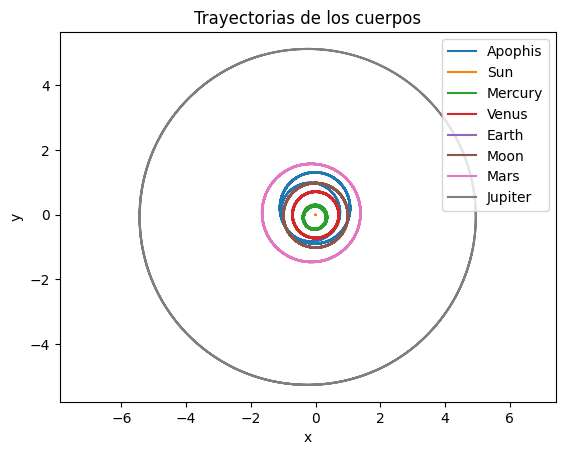

In [39]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Apophis')
plt.plot(rps[1,:,0], rps[1,:,1], label='Sun')
plt.plot(rps[2,:,0], rps[2,:,1], label='Mercury')
plt.plot(rps[3,:,0], rps[3,:,1], label='Venus')
plt.plot(rps[4,:,0], rps[4,:,1], label='Earth')
plt.plot(rps[5,:,0], rps[5,:,1], label='Moon')
plt.plot(rps[6,:,0], rps[6,:,1], label='Mars')
plt.plot(rps[7,:,0], rps[7,:,1], label='Jupiter')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

Animaciones

In [40]:
def animar_sistema_2d(rs, ts):
 fig, ax = plt.subplots(figsize=(6, 6))
 camera = Camera(fig)

 # Limit the animation to Apophis through Jupiter.
 n_particles = min(5, rs.shape[0])
 rs = rs[:n_particles]

 # Fondo del grafico (una sola vez).
 ax.set_aspect('equal', adjustable='box')
 ax.grid(alpha=0.3)

 # Menos cuadros => render mas rapido.
 step = 10
 colors = plt.cm.viridis(np.linspace(0, 1, n_particles))

 for i in range(0, len(ts), step):
    for p in range(n_particles):
        # Resaltar el cuerpo central (indice 0).
        lw = 1.2 if p == 0 else 0.8
        alpha = 0.35 if p == 0 else 0.2
        ms = 7 if p == 0 else 3

        ax.plot(rs[p, :, 0], rs[p, :, 1], '-', color=colors[p], lw=lw, alpha=alpha)
        ax.plot(rs[p, i, 0], rs[p, i, 1], 'o', color=colors[p], ms=ms)

    camera.snap()

 anim = camera.animate(interval=60, blit=False)
 #anim.save("my_animation.gif", writer="pillow", fps=20)
 plt.close(fig)

 return HTML(anim.to_jshtml())

In [14]:
animar_sistema_2d(rps, ts)

KeyboardInterrupt: 

# Momento lineal total

El momento lineal total $\vec{P}$ de un sistema de $N$ partículas se define como la suma vectorial de los momentos lineales de cada partícula individual:

$$ \vec{P} = \sum_{i=1}^{N} m_i \vec{v}_i $$

Donde:
- $m_i$ es la masa de la partícula $i$.
- $\vec{v}_i$ es el vector de velocidad de la partícula $i$.

Dado que al integrar estamos utilizando el comando `sim_solar.move_to_com()`, este traslada el sistema de referencia al centro de masa en cada iteración. En el marco de referencia del centro de masa, el momento lineal total de un sistema aislado siempre es vectorialmente nulo ($\vec{P} \approx \vec{0}$). Cualquier ligera desviación observada al imprimir la suma ($< 10^{-15}$) se debe puramente a la precisión de punto flotante de la máquina durante los cálculos numéricos. Las celdas a continuación calculan $\vec{P}$ al inicio ($t=0$) y al final ($t=999$) de la integración, demostrando que este valor se mantiene constante (cero).

In [41]:
suma = 0
for i in range(N):
    suma += sim_solar.particles[i].m*vps[i,0,:]
print(suma)

[-9.63381070e-20  1.27861443e-20 -7.78816396e-22]


In [42]:
suma_t = 0
for i in range(N):
    suma_t += sim_solar.particles[i].m*vps[i,999,:]
print(suma_t)

[-2.24261791e-21 -5.09177230e-20  2.10940750e-22]


# Momento angular total

El momento angular total $\vec{L}$ de un sistema de $N$ partículas con respecto al origen (en este caso el centro de masa) se define como la suma vectorial de los momentos angulares individuales:

$$ \vec{L} = \sum_{i=1}^{N} m_i (\vec{r}_i \times \vec{v}_i) $$

Donde:
- $m_i$ es la masa de la partícula $i$.
- $\vec{r}_i$ es el vector de posición de la partícula $i$.
- $\vec{v}_i$ es el vector de velocidad de la partícula $i$.

Dado que nuestro sistema está aislado y sujeto únicamente a fuerzas gravitacionales internas (que son fuerzas centrales), el momento angular total debe conservarse a lo largo del tiempo. Las celdas a continuación calculan el momento angular total al inicio de la simulación ($t=0$) y al final ($t=999$). Podremos observar que el vector $\vec{L}$ se mantiene prácticamente idéntico, demostrando la conservación del momento angular. Las minúsculas variaciones que puedan existir provienen exclusivamente de los errores de redondeo de punto flotante propios de la integración numérica.

In [43]:
suma = 0
for i in range(N):
    suma += sim_solar.particles[i].m * np.cross(rps[i,0,:], vps[i,0,:])
print(suma)

[9.27953303e-05 2.94751317e-05 3.53354220e-03]


In [44]:
sumat_t = 0
for i in range(N):
  sumat_t += sim_solar.particles[i].m * np.cross(rps[i,999,:], vps[i,999,:])
print(sumat_t)

[9.27953303e-05 2.94751317e-05 3.53354220e-03]


# Energía Cinética, Potencial y Total

La **Energía Cinética ($K$)** del sistema de $N$ partículas, está dada por la suma de la energía cinética de cada uno de sus componentes:

$$ K = \sum_{i=1}^{N} \frac{1}{2} m_i v_i^2 $$

Donde $m_i$ y $v_i$ corresponden a la masa y a la rapidez (magnitud del vector velocidad) del cuerpo $i$.

La **Energía Potencial Gravitacional ($U$)** se debe a la interacción atractiva mutua entre todos los pares de partículas del sistema. Dado que en nuestras unidades canónicas la constante de gravitación universal $G=1$, la energía potencial total se calcula como la suma sobre todas las combinaciones únicas de pares:

$$ U = - \sum_{i=1}^{N} \sum_{j=i+1}^{N} \frac{G m_i m_j}{|\vec{r}_i - \vec{r}_j|} $$

Donde $|\vec{r}_i - \vec{r}_j|$ es la distancia entre los cuerpos $i$ y $j$.

Finalmente, la **Energía Mecánica Total ($E$)** del sistema consiste simplemente en la suma de ambas energías:

$$ E = K + U $$

Así como el momento lineal y el angular, dado que este es un sistema de $N$ cuerpos bajo fuerzas exclusivas de gravedad (un sistema conservativo), la **energía mecánica total debe conservarse**. El siguiente bloque de código evaluará específicamente $K$, $U$ y $E$ en el último paso temporal ($t=999$) a modo de ejemplo numérico, aunque posteriormente verificaremos su consistencia a través del tiempo.

El hecho de que la energia total sea negativa indica que el sistema esta ligado

In [45]:
K = 0
for i in range(N):
    K += 0.5 * sim_solar.particles[i].m * (vps[i,999,0]**2 + vps[i,999,1]**2 + vps[i,999,2]**2)
print(K)

0.00012144886351398412


In [47]:
G = 1
U = 0
for i in range(N):
    for j in range(i + 1, 10):
        rij = np.linalg.norm(rps[i,999,:] - rps[j,999,:])
        U += -G * sim_solar.particles[i].m * sim_solar.particles[j].m / rij
print(U)

-0.00023197229768025498


In [48]:
E = K + U
print(E)

-0.00011052343416627086


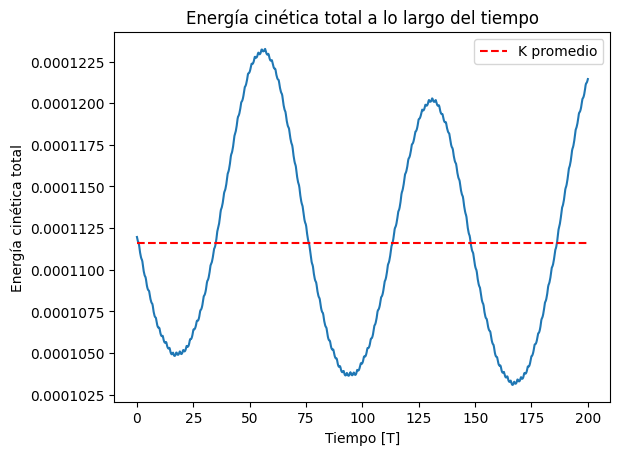

In [49]:
K_t = np.zeros(1000)
for i in range(1000):
    for j in range(N):
        K_t[i] += 0.5 * sim_solar.particles[j].m * (vps[j,i,0]**2 + vps[j,i,1]**2 + vps[j,i,2]**2)

plt.plot(ts, K_t)
plt.hlines(np.mean(K_t), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='K promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía cinética total')
plt.legend()
plt.title('Energía cinética total a lo largo del tiempo')
plt.show() 

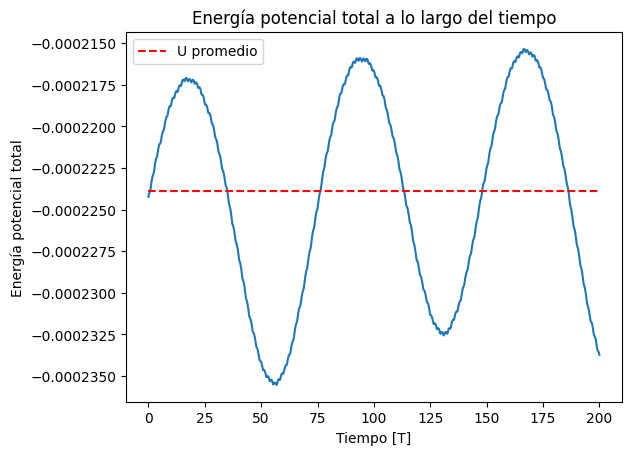

In [50]:
U_t = np.zeros(1000)
for i in range(1000):
    for j in range(N):
        for k in range(j + 1, N):
            rij = np.linalg.norm(rps[j,i,:] - rps[k,i,:])
            U_t[i] += -G * sim_solar.particles[j].m * sim_solar.particles[k].m / rij

plt.plot(ts, U_t)
plt.hlines(np.mean(U_t), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='U promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía potencial total')
plt.legend()
plt.title('Energía potencial total a lo largo del tiempo')
plt.show() 

La energía total permanece constante durante todo el tiempo de integración

Text(0.5, 1.0, 'Energía total a lo largo del tiempo')

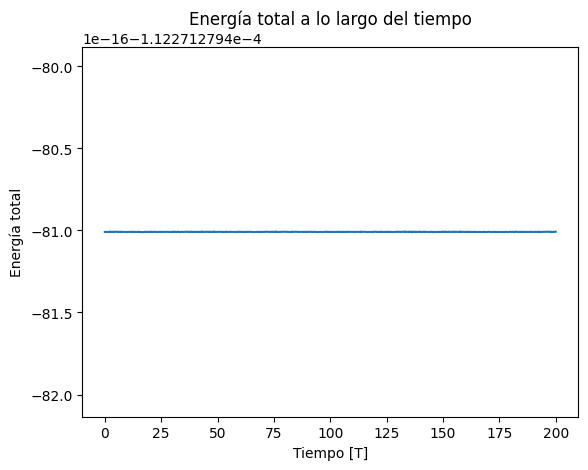

In [51]:
E_t = K_t + U_t
plt.plot(ts, E_t)
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía total')
plt.title('Energía total a lo largo del tiempo')

# Teorema del Virial y la Identidad de Lagrange-Jacobi

Además de medir la energía mecánica total, podemos estudiar la dinámica del sistema a través de la magnitud $G$, la cual está definida matemáticamente mediante el producto punto escalar:

$$ G = \sum_{i=1}^{N} m_i (\vec{r}_i \cdot \vec{v}_i) $$

Si derivamos $G$ con respecto al tiempo, obtenemos la **Identidad de Lagrange-Jacobi**:

$$ \frac{dG}{dt} = \sum_{i=1}^{N} m_i (\vec{v}_i \cdot \vec{v}_i + \vec{r}_i \cdot \vec{a}_i) = 2K + U $$

Donde $K$ es la energía cinética total y $U$ es la energía potencial total. El **Teorema del Virial** establece que, para un sistema auto-gravitante ligado (bound system) que se encuentra en equilibrio dinámico, el promedio temporal de esta derivada debe ser cero:

$$ \left\langle \frac{dG}{dt} \right\rangle = \langle 2K + U \rangle = 0 $$

En la siguiente celda se calcula y se grafica $\frac{dG}{dt}$ a lo largo del tiempo. Posteriormente se añade una línea de promedio; si nuestro sistema planetario presenta estabilidad a largo plazo, deberíamos observar que dicho promedio oscila muy cerca al cero.

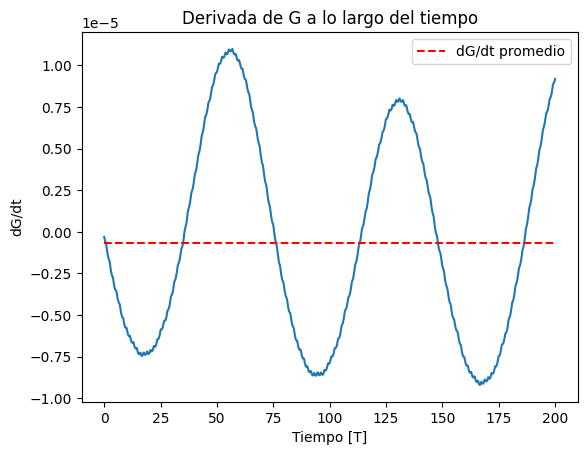

In [52]:
dG_dt = 2 * K_t + U_t
plt.plot(ts, dG_dt)
plt.hlines(np.mean(dG_dt), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='dG/dt promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('dG/dt')
plt.title('Derivada de G a lo largo del tiempo')
plt.legend()
plt.show()

# Distancia entre Tierra y apophis

Se gráfican las distancias entre Apophis y la Tierra durante todo el tiempo de integración.

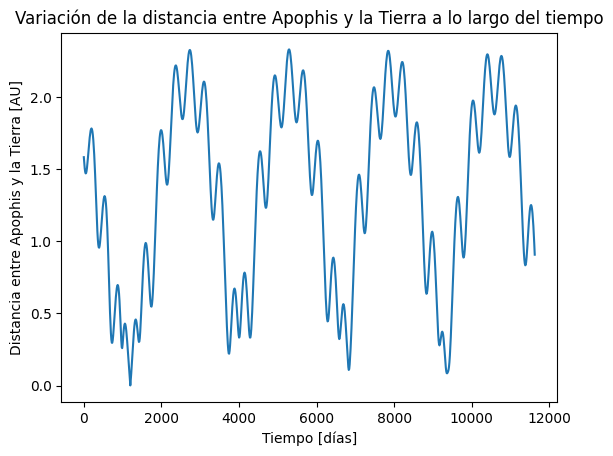

In [70]:
rps_apohis_earth = np.sqrt(np.sum((rps[0,:,:] - rps[4,:,:])**2, axis=1))
ts_days = ts * Tc_to_days

plt.plot(ts_days, rps_apohis_earth)
plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia entre Apophis y la Tierra [AU]')
plt.title('Variación de la distancia entre Apophis y la Tierra a lo largo del tiempo')
plt.show()

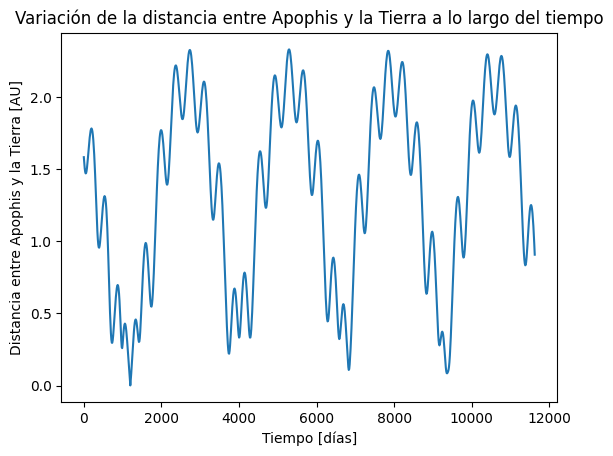

In [71]:
rps_apohis_earth2 = np.sqrt(np.sum((rps2[0,:,:] - rps2[4,:,:])**2, axis=1))
ts_days = ts * Tc_to_days

plt.plot(ts_days, rps_apohis_earth2)
plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia entre Apophis y la Tierra [AU]')
plt.title('Variación de la distancia entre Apophis y la Tierra a lo largo del tiempo')
plt.show()

Se calcula la distancia mínima entre Apophis y la Tierra, siendo esta de alrededor de $100$ mil km. Ocurriendo el 13 de Abril del 2029

In [73]:
for i in range(len(rps_apohis_earth)):
    if rps_apohis_earth[i] == rps_apohis_earth.min():
        close_time = i
        print(f'sim_solar: {rps_apohis_earth[i]:.6f} AU = {rps_apohis_earth[i]*149597870.7:.2f} km en t = {ts[i]*Tc_to_days:.2f} días a partir del primero de enero del 2026.')

for i in range(len(rps_apohis_earth2)):
    if rps_apohis_earth2[i] == rps_apohis_earth2.min():
        close_time = i
        print(f'sim_solar2: {rps_apohis_earth2[i]:.6f} AU = {rps_apohis_earth2[i]*149597870.7:.2f} km en t = {ts[i]*Tc_to_days:.2f} días a partir del primero de enero del 2026.')

sim_solar: 0.000720 AU = 107696.79 km en t = 1198.73 días a partir del primero de enero del 2026.
sim_solar2: 0.000720 AU = 107696.79 km en t = 1198.73 días a partir del primero de enero del 2026.


Pero 100 km sigue siendo una distancia grande. Se hace entonces una integracion densa iterativa alrededor del tiempo de minima aproximacion ya calculado. Esta integracion devuelve un valor de alrededor de 37 km

In [68]:
# Para encontrar la distancia mínima real (ya que la simulación por pasos toma "fotos" cada ~11.6 días y se salta el periastro exacto), realizaremos una integración 
# hiper densa en la semana específica del acercamiento de abril de 2029.

# Aproximadamente a 1198.7 días desde 2026-01-01 estamos alrededor del 13 de abril de 2029.
# Vamos a extraer el tiempo canónico del mínimo y sondear a su alrededor:
t_min_aproximado = ts[close_time]

# Sondeamos un rango de +/- 15 días (en tiempo de Gauss)
ts_denso = np.linspace(t_min_aproximado - (15.0 / Tc_to_days), t_min_aproximado + (15.0 / Tc_to_days), 20000)

d_minima = float('inf')
t_minimo_exacto = 0

print("Realizando escaneo denso (micro-pasos de horas) en las dos semanas críticas...")
sim_solar2.integrate(ts_denso[0]) # retroceder/avanzar al inicio del escaneo
for t_denso in ts_denso:
    sim_solar2.integrate(t_denso)
    # 0 = Apophis, 4 = Tierra
    pos_apophis = sim_solar2.particles[0].xyz
    pos_earth = sim_solar2.particles[4].xyz
    dist = np.linalg.norm(np.array(pos_apophis) - np.array(pos_earth))
    
    if dist < d_minima:
        d_minima = dist
        t_minimo_exacto = t_denso

print(f"La **verdadera** distancia mínima evaluada iterativamente es: {d_minima * AU_to_km:.2f} km")
print(f"Ocurrida en el día {t_minimo_exacto * Tc_to_days:.4f} desde 2026-01-01.")

Realizando escaneo denso (micro-pasos de horas) en las dos semanas críticas...


La **verdadera** distancia mínima evaluada iterativamente es: 37654.64 km
Ocurrida en el día 1198.9063 desde 2026-01-01.


Visualizamos el movimiento relativo de Apophis centrado en la Tierra (`rps_pLrel = rps_apohis - rps_earth`) a lo largo de un marco temporal de $\pm 100$ pasos simulados centrado alrededor del tiempo de acercamiento máximo (`close_time`). 

Esta visualización en 2D nos mostrará la marcada traza curva de encuentro cercano (o "flyby") que Apophis realizará y cómo se aproximará críticamente al origen (donde graficaremos un punto estático que representará el área local terrestre).

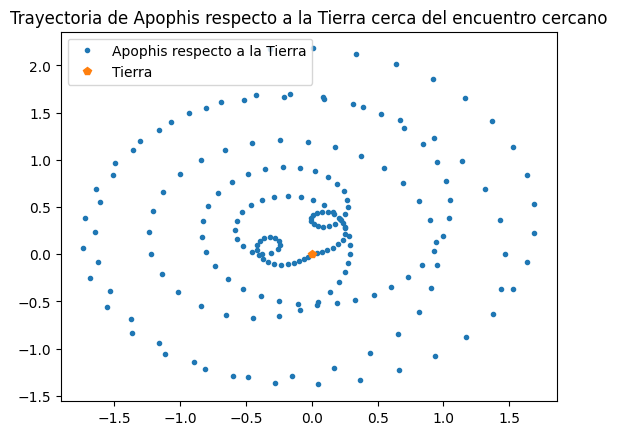

In [33]:
rps_pLrel = rps[0,:,:] - rps[4,:,:]
plt.plot(rps_pLrel[close_time-100:close_time+100,0], rps_pLrel[close_time-100:close_time+100,1], '.', label='Apophis respecto a la Tierra')
plt.plot(0,0,'p', label='Tierra')
plt.title('Trayectoria de Apophis respecto a la Tierra cerca del encuentro cercano')
plt.legend()

# Elementos orbitales de Apophis

Para comprender la geometría y orientación de la órbita de Apophis en el espacio, calcularemos sus **elementos orbitales clásicos** a partir de sus vectores de estado cartesianos (posición $\vec{r}$ y velocidad $\vec{v}$). 

Los elementos principales a deducir serán los siguientes:

**1. Momento angular específico ($\vec{h}$):** 
$$ \vec{h} = \vec{r} \times \vec{v} $$
Su magnitud $h = |\vec{h}|$ cuantifica el giro orbital. A partir de ella se obtiene el *parámetro de la órbita* (semi-latus rectum): $p = \frac{h^2}{\mu}$.

**2. Vector excentricidad ($\vec{e}$):** 
$$ \vec{e} = \frac{\vec{v} \times \vec{h}}{\mu} - \frac{\vec{r}}{r} $$
El cual apunta hacia el periastro (punto más cercano al Sol). Su magnitud corresponde a la excentricidad orbital $e = |\vec{e}|$.

**3. Vector nodo ($\vec{n}$):** 
$$ \vec{n} = \hat{k} \times \vec{h} $$
Este vector define la línea de los nodos (la intersección del plano orbital con el plano de referencia eclíptico).

**4. Inclinación ($I$):** 
El ángulo entre el plano orbital y el plano de referencia eclíptico.
$$ I = \arccos\left(\frac{h_z}{h}\right) $$

**5. Longitud del nodo ascendente ($\Omega$):** 
El ángulo desde el punto de referencia (el punto Aries) hasta el vector nodo $\vec{n}$.
$$ \Omega = \arccos\left(\frac{n_x}{n}\right) $$
*(Si la componente $y$ de $\vec{n}$ es negativa, entonces $\Omega = 360^{\circ} - \Omega$)*

**6. Argumento del periastro ($\omega$):** 
El ángulo desde el vector nodo hasta el periastro.
$$ \omega = \arccos\left(\frac{\vec{n} \cdot \vec{e}}{n e}\right) $$
*(Si la componente $z$ de $\vec{e}$ es negativa, entonces $\omega = 360^{\circ} - \omega$)*

**7. Anomalía verdadera ($f$):** 
La posición angular del cuerpo medida desde el periastro.
$$ f = \arccos\left(\frac{\vec{e} \cdot \vec{r}}{e r}\right) $$
*(Si el producto punto de $\vec{r}$ con $\vec{v}$ es negativo, entonces $f = 360^{\circ} - f$)*

Los bloques de código siguientes extraen el estado inicial mediante JPL Horizons y aplican esta misma receta matemática para calcular dichos componentes.

In [76]:
#posicion y velocidad de Apophis
tabla, jd, X = pc.consulta_horizons(id="Apophis",epochs="2026-01-01",location="@SSB")
#X: vector de estado (posicion y velocidad) en SI
print(X)

[ 9.43506820e+10 -5.94965529e+10  5.39320176e+09  1.96416067e+04
  3.20816729e+04 -1.24824123e+03]


In [77]:
rvec = X[:3] #posicion
r = np.linalg.norm(rvec) #magnitud de la posicion
vvec = X[3:] #velocidad
v = np.linalg.norm(vvec) #magnitud de la velocidad

hvec = np.cross(rvec,vvec) #vector momento angular especifico
h = np.linalg.norm(hvec) #magnitud del momento angular especifico en m^2/s

AU = 149597870700 # 1 AU en metros
h_au = h / (AU**2) # magnitud del momento angular especifico en AU^2/s

print(f"h: {h} m^2/s")
print(f"h (AU): {h_au} AU^2/s")

h: 4202655732937966.0 m^2/s
h (AU): 1.8779022896697405e-07 AU^2/s


In [78]:
#Aprox, mu = mu del sol
mu = pc.constantes.mu_sun
evec = np.cross(vvec,hvec)/mu - rvec/r #vector excentricidad

nvec = np.cross([0,0,1],hvec) #vector nodo
n = np.linalg.norm(nvec) #magnitud del nodo

In [79]:
def orbital_elements_from_state(rvec, vvec, mu):
    """
    Compute classical orbital elements from state vectors.

    Parameters
    ----------
    rvec : array-like, shape (3,)
        Position vector.
    vvec : array-like, shape (3,)
        Velocity vector.
    mu : float
        Standard gravitational parameter of the central body.

    Returns
    -------
    p : float
        Semi-latus rectum.
    e : float
        Eccentricity magnitude.
    I : float
        Inclination (rad).
    Omega : float
        Longitude of ascending node (rad).
    omega : float
        Argument of periapsis (rad).
    f : float
        True anomaly (rad).
    """
    rvec = np.asarray(rvec, dtype=float)
    vvec = np.asarray(vvec, dtype=float)

    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    nvec = np.cross([0.0, 0.0, 1.0], hvec)
    n = np.linalg.norm(nvec)

    p = h**2 / mu
    I = np.arccos(np.clip(hvec[2] / h, -1.0, 1.0))

    # Handle near-equatorial / near-circular edge cases safely.
    if n > 0 and e > 0:
        omega_p = np.arccos(np.clip(np.dot(nvec, evec) / (n * e), -1.0, 1.0))
        omega = 2 * np.pi - omega_p if evec[2] < 0 else omega_p

        Omega_p = np.arccos(np.clip(np.dot([1.0, 0.0, 0.0], nvec) / n, -1.0, 1.0))
        Omega = 2 * np.pi - Omega_p if nvec[1] < 0 else Omega_p
    else:
        omega = 0.0
        Omega = 0.0

    if e > 0:
        f_p = np.arccos(np.clip(np.dot(evec, rvec) / (e * r), -1.0, 1.0))
        f = 2 * np.pi - f_p if np.dot(rvec, vvec) / r < 0 else f_p
    else:
        f = 0.0

    return p, e, I, Omega, omega, f


p, e, I, Omega, omega, f = orbital_elements_from_state(rvec, vvec, mu)

rad = 180 / np.pi
print(f"p: {p}")
print(f"e: {e}")
print(f"inclinacion: {I * rad} grados")
print(f"longitud del nodo ascendente: {Omega * rad} grados")
print(f"argumento del periastro: {omega * rad} grados")
print(f"anomalia verdadera: {f * rad} grados")


p: 133087110779.53651
e: 0.19256324534681835
inclinacion: 3.335653903430258 grados
longitud del nodo ascendente: 203.81969272317235 grados
argumento del periastro: 129.16262131692844 grados
anomalia verdadera: 354.73759405404843 grados


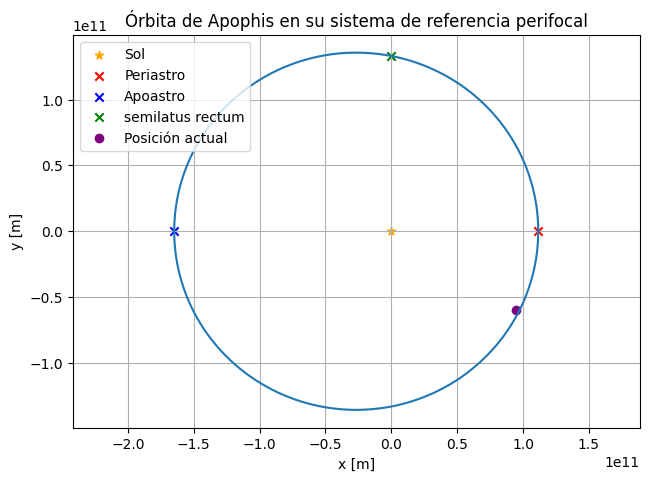

Periastro: 0.7459834019939824 AU
Apoastro: 1.101798229681689 AU
Semilatus rectum: 0.8896323868568038 AU
posición actual: (0.6306953539299172 AU, -0.3977098912292629 AU)


In [80]:
#Orbita de Apophis en su sistema de referencia perifocal

tetaers = np.linspace(0, 2 * np.pi, 1000)
rs = p / (1 + e * np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)

q = p / (1 + e)
Q = p / (1 - e)

plt.plot(xfs, yfs)
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.title('Órbita de Apophis en su sistema de referencia perifocal')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.scatter(0,0, marker='*', color='orange', label='Sol')
plt.scatter(q,0, marker='x', color='red', label='Periastro')
plt.scatter(-Q,0, marker='x', color='blue', label='Apoastro')
plt.scatter(0,p, marker='x', color='green', label='semilatus rectum')
plt.scatter(X[0], X[1], marker='o', color='purple', label='Posición actual')
plt.legend(loc="upper left")
plt.show()

print(f"Periastro: {q/AU} AU")
print(f"Apoastro: {Q/AU} AU")
print(f"Semilatus rectum: {p/AU} AU")
print(f"posición actual: ({X[0]/AU} AU, {X[1]/AU} AU)")

In [85]:
# Gráfica 3D interactiva de la órbita de Apophis con Plotly
fig = go.Figure()

# Trazar la órbita de Apophis (de la simulación)
fig.add_trace(go.Scatter3d(
    x=rps[0, :, 0],
    y=rps[0, :, 1],
    z=rps[0, :, 2],
    mode='lines',
    name='Apophis',
    line=dict(color='purple', width=4)
))

# Trazar la órbita de la Tierra
fig.add_trace(go.Scatter3d(
    x=rps[4, :, 0],
    y=rps[4, :, 1],
    z=rps[4, :, 2],
    mode='lines',
    name='Tierra',
    line=dict(color='blue', width=3)
))

# Trazar el Sol
fig.add_trace(go.Scatter3d(
    x=rps[1, :, 0],
    y=rps[1, :, 1],
    z=rps[1, :, 2],
    mode='lines',
    name='Sol',
    line=dict(color='orange', width=5)
))

# Configuración del diseño
fig.update_layout(
    title='Órbita de Apophis en 3D',
    scene=dict(
        xaxis_title='X [AU]',
        yaxis_title='Y [AU]',
        zaxis_title='Z [AU]',
        aspectmode='data'
    ),
    width=800,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# El Hodógrafo de Velocidad

El **hodógrafo** es una representación gráfica del movimiento de un cuerpo en el **espacio de velocidades** en lugar del espacio de configuración u orbital. En mecánica celeste, la trayectoria de un cuerpo sometido a una fuerza recíproca al cuadrado de la distancia (como la gravedad newtoniana) siempre traza una **circunferencia perfecta** en el diagrama de hodógrafo de velocidades, sin importar la excentricidad real de su órbita (ya sea circular, elíptica, parabólica o hiperbólica).

Las componentes de la velocidad en el plano orbital a lo largo del tiempo, o dependientes de la anomalía verdadera $\theta$, están dadas por:

$$ v_x = -\left(\frac{\mu}{h}\right) \sin(\theta) $$
$$ v_y = \left(\frac{\mu}{h}\right) (e + \cos(\theta)) $$

La diferencia fundamental radica en el **origen de velocidades** referenciado al centro geométrico del hodógrafo. El centro de dicha circunferencia nunca se ubica en el origen $(0,0)$ a menos que la órbita sea perfectamente circular ($e = 0$). Comúnmente el centro de esta circunferencia de radio $\frac{\mu}{h}$ estará desplazado verticalmente por una magnitud dictada por la excentricidad: $\left(0, \frac{\mu e}{h}\right)$.

El siguiente código dibuja el hodógrafo de las velocidades teóricas de Apophis trazadas sobre el plano perifocal, donde demarcaremos con una 'x' dicho centro excéntrico y con un punto púrpura el vector de velocidad actual extraído de Horizons.

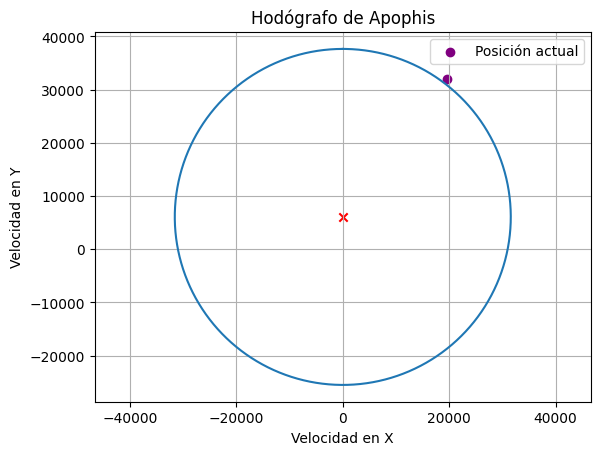

In [81]:
vx = -(mu/h)*np.sin(tetaers)
vy = (mu/h)*(e + np.cos(tetaers))

plt.plot(vx, vy)
plt.scatter(0,(mu*e)/h,marker="x",color="red")
plt.scatter(vvec[0], vvec[1], marker='o', color='purple', label='Posición actual')
plt.xlabel('Velocidad en X')
plt.ylabel('Velocidad en Y')
plt.title('Hodógrafo de Apophis')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


# Aproximación Analítica de la Posición en el Encuentro Cercano

A diferencia de la integración numérica de $N$-cuerpos que hemos utilizado previamente, podemos intentar **predecir analíticamente** la posición de Apophis para la fecha de su máximo acercamiento (13 de Abril de 2029) asumiendo por un momento un **problema de 2 cuerpos no perturbado** (Apophis - Sol). Toda la teoría descrita a continuación se implementa en las siguientes celdas.

Las ecuaciones clásicas empleadas son:

**1. Semiejes y movimiento medio:**
Usamos el *semilatus rectum* ($p$) y la excentricidad ($e$) para hallar el semieje mayor $a = \frac{p}{1 - e^2}$ y menor $b = a\sqrt{1 - e^2}$. A partir de estos, hallamos el **movimiento medio** ($n$) (la velocidad angular promedio del asteroide):
$$ n = \frac{h}{ab} $$

**2. Anomalía Media ($M$):**
El cambio angular general que tendría el cuerpo si su órbita fuese perfectamente circular, basándonos en el tiempo transcurrido desde el paso por su perihelio más reciente ($t_p$) hasta el tiempo objetivo ($t$):
$$ M = n (t - t_p) $$

**3. Anomalía Excéntrica ($E$) a través de la Ecuación de Kepler:**
La famosa Ecuación de Kepler $M = E - e \sin(E)$ es trascendental y no tiene solución directa. Por ende, la aproximamos utilizando una expansión de series hasta segundo orden:
$$ E \approx M + e \sin(M) + \frac{e^2}{2} \sin(2M) $$

**4. Anomalía Verdadera ($f$) y Radio Analítico ($r$):**
Una vez tenemos $E$, hallamos la posición real angular en la elipse o **anomalía verdadera** $f$:
$$ \tan\left(\frac{f}{2}\right) = \sqrt{\frac{1+e}{1-e}} \tan\left(\frac{E}{2}\right) $$
Para luego, evaluar la ecuación polar de la cónica para la distancia en el instante del acercamiento:
$$ r_f = \frac{p}{1 + e\cos(f)} $$

**5. Transformación al Sistema de Referencia 3D Espacial:**
El cuerpo en su plano (perifocal) se encuentra en las coordenadas paramétricas $x = r_f \cos(f)$, $y = r_f \sin(f)$, $z = 0$. 
Para conocer sus coordenadas $XYZ$ en nuestro marco de referencia global, se le aplica una **Matriz de Rotación** usando los ángulos de Euler dados por sus elementos orbitales: Argumento del periastro ($\omega$), Inclinación ($I$) y Longitud del nodo ascendente ($\Omega$). 
Dicha matriz rotacional se computará a través de la herramienta `SPICE` de la NASA y nos devolverá nuestro **estado final**. Tras obtener este estado puramente analítico, se somete a comparación con el vector traído estrictamente de **JPL Horizons** para evidenciar la desviación generada por ignorar las perturbaciones del resto de planetas del sistema.

In [82]:
a = p / (1 - e**2)
print(f"Semieje mayor: {a/AU} AU")
b = a * np.sqrt(1 - e**2)
print(f"Semieje menor: {b/AU} AU")

n = h/(a*b) #velocidad angular media en rad/s

Semieje mayor: 0.9238908158378356 AU
Semieje menor: 0.9065997968722987 AU


In [84]:
tp = 2461042.918242006079 * 86400
t = Time('2029-04-13 00:00:00', scale='tdb').jd * 86400 # tiempo del encuentro cercano en segundos

M = n * (t - tp)
E = M + e * np.sin(M) + e**2/2 * np.sin(2*M)
E = np.mod(E, 2 * np.pi)
print(f"Anomalia excéntrica en el encuentro cercano: {np.degrees(E)} grados")

f = 2 * np.arctan(np.sqrt((1+e)/(1-e)) * np.tan(E/2))
f = np.mod(f, 2 * np.pi)
print(f"Anomalia verdadera en el encuentro cercano: {np.degrees(f)} grados")

rf = p / (1 + e * np.cos(f))
print(f"Distancia en el encuentro cercano: {rf*m_to_AU} AU")

xf = rf * np.cos(f)
yf = rf * np.sin(f)
zf = 0

R = spy.eul2m(-Omega, -i, -omega, 3, 1, 3)

r = R @ np.array([xf, yf, zf])
print(r)


Anomalia excéntrica en el encuentro cercano: 238.55620391950558 grados
Anomalia verdadera en el encuentro cercano: 229.53161439549643 grados
Distancia en el encuentro cercano: 1.0166983392247986 AU
[-1.40503652e+11 -5.82398517e+10  9.17116021e+07]


In [43]:
tabla, jd, X = pc.consulta_horizons(id='Apophis', location='@SSB', epochs='2029-04-13 00:00:00')
X[:3]

c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


array([-1.38330773e+11, -5.88849780e+10, -1.20616566e+08])

# Evolucion de los elementos orbitales
Se calculan los elementos orbitales de Apophis para cada primer dia de los años incluidos en la integración (ademas del dia de mayor acercamiento) para evidenciar el cmabio provocado por el contacto cercano con la Tierra. Los cambios más destacados se evidencian en el semilatus rectum, la inclinación y en el argumento del periastro.

In [67]:
dates = ["2026-01-01", "2027-01-01", "2028-01-01", "2029-01-01", "2029-04-13", "2030-01-01", "2031-01-01","2032-01-01", "2033-01-01", "2034-01-01"]
p_s = []
e_s = []
I_s = []
Omega_s = []
omega_s = []
f_s = []

for i in range(len(dates)):
    tabla, jd, X = pc.consulta_horizons(id="Apophis", epochs=dates[i], location="@SSB")
    rvec = X[:3] #posicion
    vvec = X[3:] #velocidad

    p, e, I, Omega, omega, f = orbital_elements_from_state(rvec, vvec, mu)

    p_s.append(p)
    e_s.append(e)
    I_s.append(I)
    Omega_s.append(Omega)
    omega_s.append(omega)
    f_s.append(f)

for i in range(len(p_s)):
    p_s[i] = p_s[i] / AU #pasar a AU

c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261\meccelenv312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaW

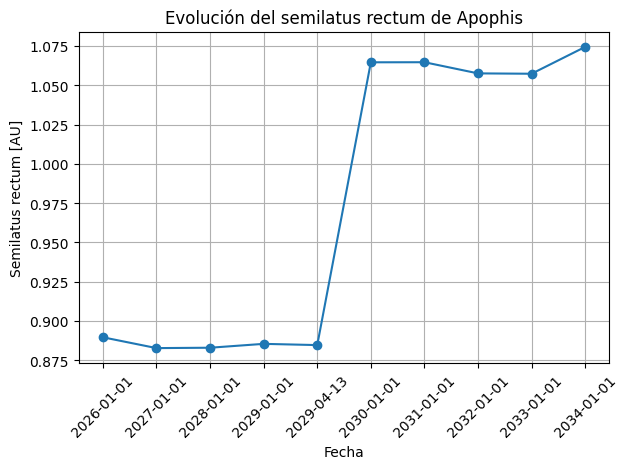

In [50]:
plt.plot(dates, p_s, marker='o')
plt.title('Evolución del semilatus rectum de Apophis')
plt.xlabel('Fecha')
plt.ylabel('Semilatus rectum [AU]')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

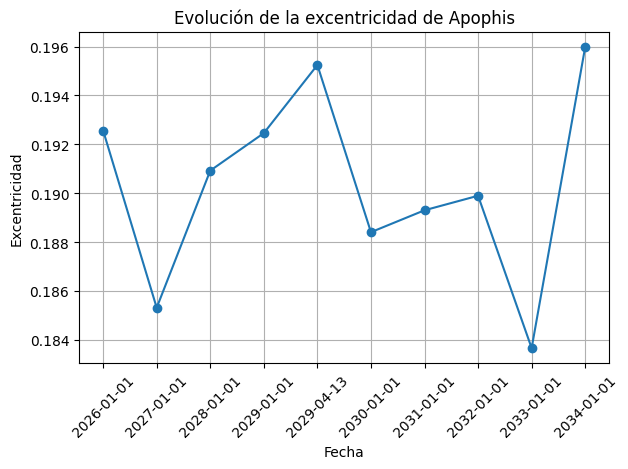

In [51]:
plt.plot(dates, e_s, marker='o')
plt.title('Evolución de la excentricidad de Apophis')
plt.xlabel('Fecha')
plt.ylabel('Excentricidad') 
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

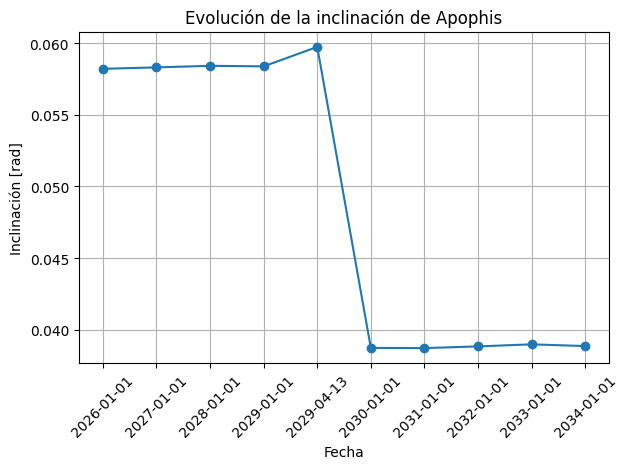

In [52]:
plt.plot(dates, I_s, marker='o')
plt.title('Evolución de la inclinación de Apophis')
plt.xlabel('Fecha')
plt.ylabel('Inclinación [rad]')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

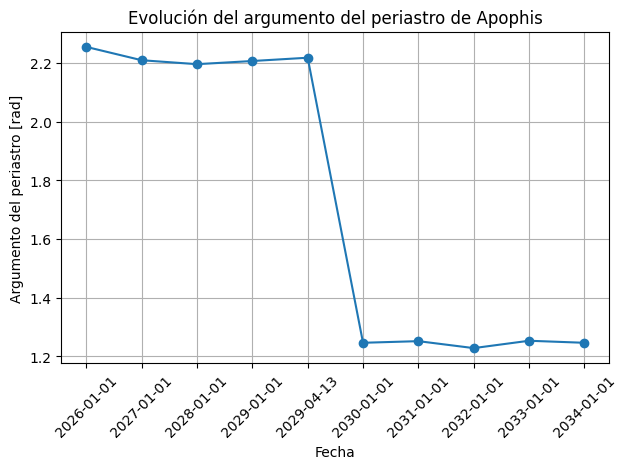

In [53]:
plt.plot(dates,omega_s, marker='o')
plt.title('Evolución del argumento del periastro de Apophis')
plt.xlabel('Fecha')
plt.ylabel('Argumento del periastro [rad]')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

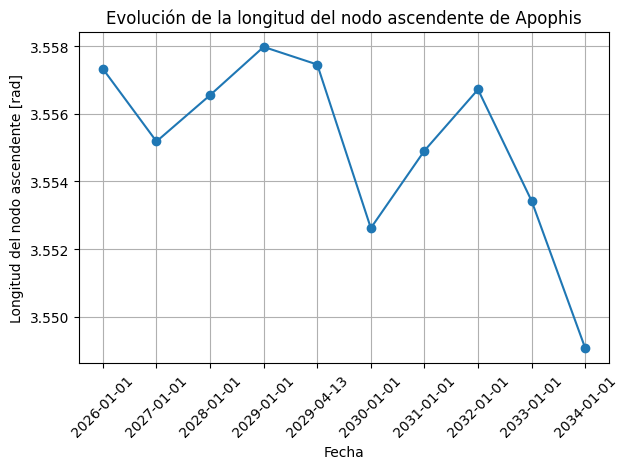

In [54]:
plt.plot(dates, Omega_s, marker='o')
plt.title('Evolución de la longitud del nodo ascendente de Apophis')
plt.xlabel('Fecha')
plt.ylabel('Longitud del nodo ascendente [rad]')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
#Cambios en los elementos orbitales de Apophis entre el 2029 y el 2030 debido al encuentro cercano con la Tierra

print("Diferencia entre elementos orbitales de Apophis entre el 2029-01-01 y el 2030-01-01:")
print(f"Semilatus rectum: {abs(p_s[4] - p_s[3])} AU")
print(f"Excentricidad: {e_s[4] - e_s[3]}")
print(f"Inclinación: {I_s[4] - I_s[3]} rad")
print(f"Argumento del perihelio: {omega_s[4] - omega_s[3]} rad")
print(f"Longitud del nodo ascendente: {Omega_s[4] - Omega_s[3]} rad")
print(f"Verdadero anomalia: {f_s[4] - f_s[3]} rad")

Diferencia entre elementos orbitales de Apophis entre el 2029-01-01 y el 2030-01-01:
Semilatus rectum: 0.0007825646670707176 AU
Excentricidad: 0.002785827258353052
Inclinación: 0.0013601887169018834 rad
Argumento del perihelio: 0.01120054355905209 rad
Longitud del nodo ascendente: -0.0005206873174152804 rad
Verdadero anomalia: 1.425065213476599 rad
